Kristal Lee\
DSC 640\
Prof. Catherine Williams\
Winter 2024\
Weeks 9 & 10

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import re

In [2]:
airport_comp = pd.read_csv("complaints-by-airport.csv")
cat_comp = pd.read_csv("complaints-by-category.csv")
subcat_comp = pd.read_csv("complaints-by-subcategory.csv")
iata = pd.read_csv("iata-icao.csv")

In [3]:
#print(airport_comp.head(5))
#print(cat_comp.head(5))
#print(subcat_comp.head(5))
#iata.head(5)

In [4]:
us_iata = iata[iata['country_code'] == 'US'].reset_index(drop=True)

In [5]:
us_iata.head()

,country_code,region_name,iata,icao,airport,latitude,longitude
0,US,Alabama,AIV,KAIV,George Downer Airport,33.1065,-88.1978
1,US,Alabama,ALX,KALX,Thomas C. Russell Field,32.9147,-85.9630
2,US,Alabama,ANB,KANB,Anniston Regional Airport,33.5882,-85.8581
3,US,Alabama,ASN,KASN,Talladega Municipal Airport,33.5699,-86.0509
4,US,Alabama,AUO,KAUO,Auburn University Regional Airport,32.6151,-85.4340


In [6]:
us_airport_codes = list(us_iata['iata'].values)

In [7]:
us_air_comp = airport_comp[airport_comp['airport'].isin(us_airport_codes)]

In [8]:
sub_cat_str1 = '*Damaged'
sub_cat_str2 = '*Damaged/Missing Items'

In [9]:
#test = sub_comp[sub_comp['clean_sub_cat']=

In [10]:
sub_cats_full = list(subcat_comp['clean_subcat'].unique())


In [11]:
filter_words1 = list(filter(lambda word: sub_cat_str1 in word, sub_cats_full))
filter_words1

['*Damaged/Missing Items--Checked Baggage',
 '*Damaged/Missing Items--Carry-on Luggage',
 '*Damaged/Missing Items',
 '*Damaged/Missing Items--C',
 '*Damaged Items - Checked',
 '*Damaged/Missing Items--Unspecified Luggage',
 '*Damaged Items',
 '*Damaged Items - Carry-On',
 '*Damaged/Missing Items Private Screening Contractor']

In [12]:
filter_words2 = list(filter(lambda word: sub_cat_str2 in word, sub_cats_full))
filter_words2

['*Damaged/Missing Items--Checked Baggage',
 '*Damaged/Missing Items--Carry-on Luggage',
 '*Damaged/Missing Items',
 '*Damaged/Missing Items--C',
 '*Damaged/Missing Items--Unspecified Luggage',
 '*Damaged/Missing Items Private Screening Contractor']

In [13]:
sub_cat_us_dm = subcat_comp[subcat_comp['clean_subcat'].isin(filter_words2)]
sub_cat_us_dm.shape

(47877, 11)

In [14]:
sub_cat_us_dm = sub_cat_us_dm[sub_cat_us_dm['airport'].isin(us_airport_codes)]
sub_cat_us_dm.head()
sub_cat_us_dm.drop(['pdf_report_date','category','subcategory','clean_cat_status','clean_subcat_status','is_category_prefix_removed'],
                    axis=1, inplace=True)

In [15]:
sub_cat_us_dm.head()
us_air_comp.head()
us_iata.head()

,country_code,region_name,iata,icao,airport,latitude,longitude
0,US,Alabama,AIV,KAIV,George Downer Airport,33.1065,-88.1978
1,US,Alabama,ALX,KALX,Thomas C. Russell Field,32.9147,-85.9630
2,US,Alabama,ANB,KANB,Anniston Regional Airport,33.5882,-85.8581
3,US,Alabama,ASN,KASN,Talladega Municipal Airport,33.5699,-86.0509
4,US,Alabama,AUO,KAUO,Auburn University Regional Airport,32.6151,-85.4340


In [16]:
sub_cat2 = pd.read_excel("us_complaints-by-subcategory-update.xls")
sub_cat2.head()

,airport,count,clean_cat,clean_subcat,State,lat,lon,EOM,Year
0,ABE,1,Mishandling of Passenger Property,*Damaged/Missing Items,Pennsylvania,40.6521,-75.4408,2016-10-31,2016
1,ABE,2,Mishandling of Passenger Property,*Damaged/Missing Items,Pennsylvania,40.6521,-75.4408,2016-11-30,2016
2,ABE,2,Mishandling of Passenger Property,*Damaged/Missing Items,Pennsylvania,40.6521,-75.4408,2016-12-31,2016
3,ABE,1,Mishandling of Passenger Property,*Damaged/Missing Items,Pennsylvania,40.6521,-75.4408,2017-01-31,2017
4,ABE,2,Mishandling of Passenger Property,*Damaged/Missing Items,Pennsylvania,40.6521,-75.4408,2017-02-28,2017


In [17]:
tops_year = pd.read_excel("top_airports_by_year.xlsx")
tops_year.head()

,airport_code,counts,year
0,LAX,1334,2015
1,JFK,1396,2015
2,MCO,1103,2015
3,MIA,989,2015
4,ATL,1048,2015


In [18]:
import seaborn as sns

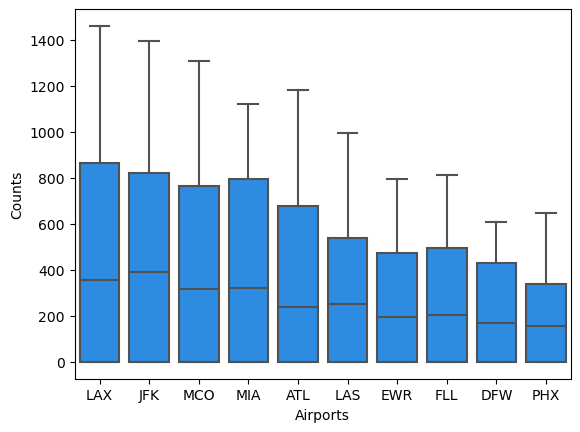

In [19]:
sns.boxplot(x='airport_code', y='counts', data=tops_year, color="#0f8dff")

plt.xlabel('Airports')
plt.ylabel('Counts')
plt.show()


In [20]:
byyear = pd.read_excel("month totals.xlsx")
byyear

,year,totals
0,2015,44005
1,2016,56536
2,2017,53300
3,2018,52140
4,2019,48956
5,2020,20616
6,2021,47409
7,2022,119708
8,2023,127489


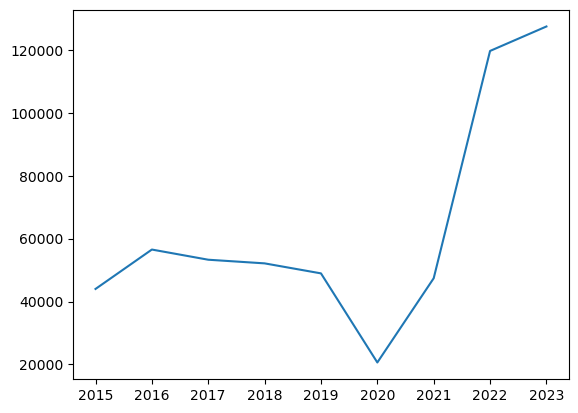

In [21]:
plt.plot(byyear['year'],byyear['totals'])

In [22]:
by_airport['count'].values

NameError: name 'by_airport' is not defined